In [19]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random

In [20]:
market = ADatabase("market")

In [21]:
queries = []
for band in tqdm([30]):
    for leverage in [15]:
        for stoploss in [.01]:
            queries.append({"band":band,"leverage":leverage,"stoploss":stoploss})

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<?, ?it/s]


In [29]:
for query in tqdm(queries):
    band = query["band"]
    leverage = query["leverage"]
    stoploss = query["stoploss"]
    market.connect()
    df = market.retrieve("xrp_futures")
    market.disconnect()
    df["date"] = [datetime.utcfromtimestamp(int(x)) for x in df["start"]]
    df.sort_values("date",inplace=True)
    df["close"] = [float(x) for x in df["close"]]
    start = df["date"].min()
    end = df["date"].max()
    # date = start
    state = {
        "filled":False,
        "buy_price":0,
        "sell_price":0,
        "signal":0,
    }
    states = []
    for date in tqdm(df["date"].values):
        try:
            current_market = df[df["date"]==date].iloc[0]
            price = current_market["close"].item()
            filled = state["filled"]
            if filled == False:
                rand_val = random.randint(0,1)
                if  rand_val == 1:
                    # long
                    state["buy_time"] = date
                    state["buy_price"] = price
                    state["sell_price"] = price
                    state["filled"] = True
                    state["signal"] = 1
                elif rand_val == 0:
                    # long
                    state["buy_time"] = date
                    state["buy_price"] = price
                    state["sell_price"] = price
                    state["filled"] = True
                    state["signal"] = -1
            elif filled == True:
                returns = (price - state["buy_price"]) / state["buy_price"] * state["signal"]
                if returns > .03 or returns < -.01:
                    state["sell_price"] = price
                    state["sell_time"] = date
                    states.append(state)
                    state = state.copy()
                    state = {
                            "filled":False,
                            "buy_price":0,
                            "sell_price":0,
                            "signal":0,
                    }      
            else:
                continue
        except Exception as e:
            print(str(e))
    portfolios = pd.DataFrame(states)
    portfolios["return"] = (portfolios["sell_price"] - portfolios["buy_price"]) / portfolios["buy_price"] * portfolios["signal"] * leverage + 1
    # portfolios["return"] = [max(x,1-stoploss*leverage) for x in portfolios["return"]]
    portfolios["cr"] = portfolios["return"].cumprod() * 100
    query["cr"] = portfolios["cr"].iloc[-1]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:15<00:00, 75.76s/it]


In [30]:
portfolios

,filled,buy_price,sell_price,signal,buy_time,sell_time,return,cr
0,True,0.4688,0.4836,1,2023-09-11 11:58:00,2023-09-12 03:28:00,1.473549,147.354949
1,True,0.4829,0.4775,1,2023-09-12 03:29:00,2023-09-12 05:01:00,0.832263,122.638132
2,True,0.4769,0.4817,-1,2023-09-12 05:03:00,2023-09-12 10:24:00,0.849025,104.122834
3,True,0.4820,0.4770,1,2023-09-12 10:25:00,2023-09-12 13:19:00,0.844398,87.921148
4,True,0.4769,0.4919,1,2023-09-12 13:20:00,2023-09-14 18:21:00,1.471797,129.402084
...,...,...,...,...,...,...,...,...
377,True,0.5715,0.5643,1,2024-02-16 02:34:00,2024-02-16 07:22:00,0.811024,0.000177
378,True,0.5651,0.5710,-1,2024-02-16 07:23:00,2024-02-16 10:32:00,0.843391,0.000149
379,True,0.5709,0.5645,1,2024-02-16 10:33:00,2024-02-16 14:18:00,0.831844,0.000124
380,True,0.5651,0.5477,-1,2024-02-16 14:19:00,2024-02-17 13:35:00,1.461865,0.000182


In [31]:
pd.DataFrame(queries).sort_values("cr",ascending=False)

,band,leverage,stoploss,cr
0,30,15,0.01,0.000152


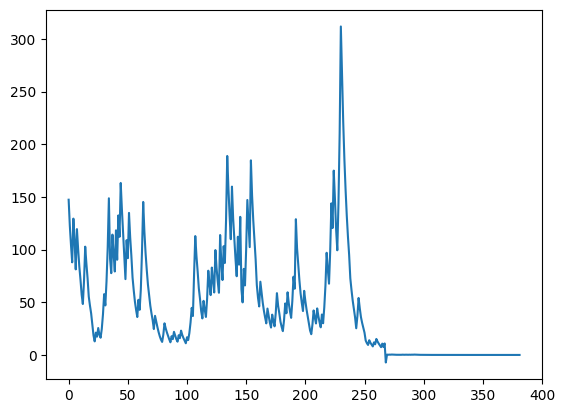

In [32]:
plt.plot(portfolios["cr"])
plt.show()

In [33]:
trades = portfolios[portfolios["return"]!=1]
trades.to_csv("random_trades.csv")